# DATOS ANOMALOS

Una definición muy simplista de un dato anómalo es aquella observación que se sale de la normalidad. En muchas ocasiones, queremos eliminar estos datos porque pueden **<u>introducir sesgos</u>** en las conclusiones derivadas de un análisis de datos o en la creación de modelos de aprendizaje automático. Sin embargo, en otros casos, detectar estos datos anómalos resulta muy valioso, ya que pueden proporcionar información relevante.

**Por ejemplo**, imaginemos una transferencia bancaria con una cantidad exorbitante: es muy probable que se trate de un error o incluso de un fraude. Ya sea para eliminarlos o para extraer información de ellos, existen diversas técnicas para identificar datos anómalos.

# BOSQUES DE AISLAMIENTO

Veremos **los bosques de aislamiento**, una técnica ampliamente utilizada para detectar este tipo de datos.

Cabe mencionar que los bosques de aislamiento también se conocen en inglés como Isolation Forests. Estos bosques están formados por un conjunto de **múltiples árboles de aislamiento**, conocidos como iTrees, y cada uno de ellos se crea de manera **completamente aleatoria**. En los Isolation Trees, los cortes son **completamente aleatorios**.

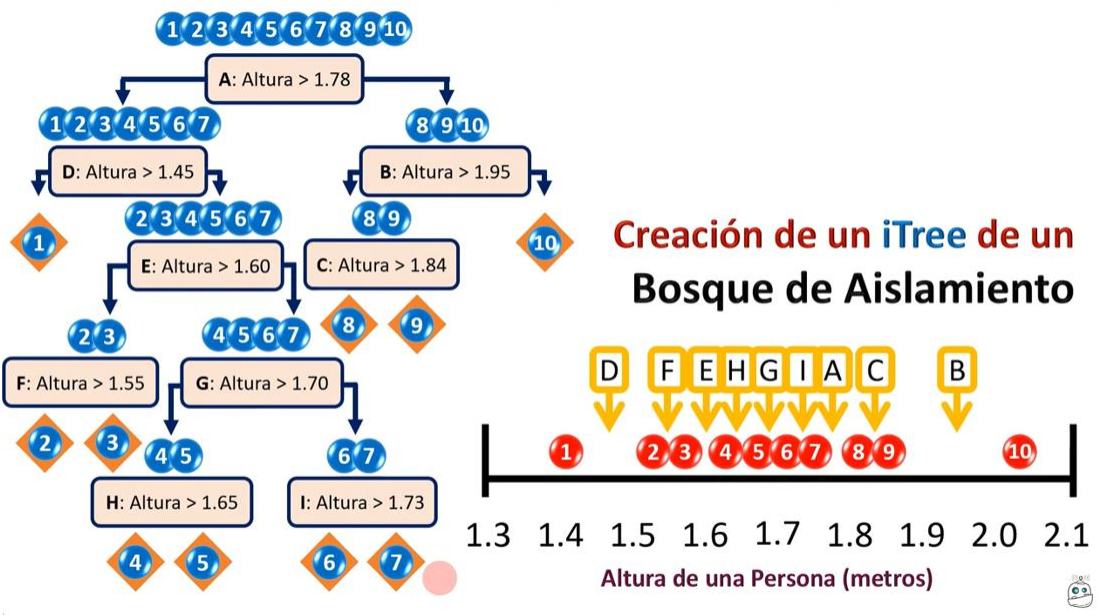

**Posicion de los datos anómalos:**

Las personas extremadamente bajitas o muy altas se encuentran en ramas cercanas a la raíz del árbol, ocupando posiciones elevadas (por ejemplo, en los nodos 1 y 10). En contraste, las personas con alturas cercanas al promedio se agrupan en la parte inferior del árbol. Esto ilustra cómo el método está caracterizando aquellos datos que son fácilmente separables.

Un dato es **fácilmente separable** cuando sus valores difieren significativamente de los de la mayoría. Por ello, estos datos suelen ubicarse en la **parte superior** del árbol. En cambio, aquellos datos que son **difíciles de separar**, al formar parte del grupo predominante, tienden a quedar en la parte inferior.

**Muestreo aleatorio:**

Si contamos con un millón de datos, no es necesario segmentarlos todos individualmente. Lo que hace el método es realizar un **muestreo aleatorio** para la creación de cada árbol. Es decir, cada árbol se construye utilizando un subconjunto diferente de datos. Además, se realiza un **muestreo aleatorio de las características**; en este ejemplo solo contábamos con una, pero podríamos tener tres o cuatro, las cuales también se seleccionan aleatoriamente para la formación de los árboles.

**Inferencia:**

Cuando llega una nueva instancia, esta se evalúa en todos los árboles creados.
La posición en la que se ubica, determinada por la **altura promedio en el árbol**, es utilizada para asignarle una **puntuación de anomalía**.

**Nivel de contaminacion:**

¿Cómo determinamos qué es un dato anómalo y qué es un dato normal? ¿En qué punto se define, por ejemplo, altura 1, altura 2, altura 3 como anómalos o normales?" Para ello, es necesario establecer un umbral, conocido como nivel de contaminación. En el caso de iForest, debemos especificar aproximadamente qué porcentaje de la base de datos consideramos anómalo. Este porcentaje puede ser, por ejemplo, 1%, 5%, 10% o 15%, dependiendo del dominio. Por lo general, se determina mediante experimentación.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [3]:
# Cargar datos
#carros = np.loadtxt("carros_usados.csv", delimiter=",")
carros = np.loadtxt("carros.csv", delimiter=",", skiprows=1) #km / precio
resultados = np.zeros((3, carros.size//2))

In [4]:
resultados

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0.]])

In [5]:
carros #km / precio

array([[   6048., 1385956.],
       [  11825., 1297582.],
       [  20000., 1000000.],
       [  21048., 1284844.],
       [  21549.,  685300.],
       [  21613., 1342000.],
       [  24184., 1207484.],
       [  25000., 1005000.],
       [  27027.,  655402.],
       [  27863.,  814000.],
       [  27863.,  814000.],
       [  29189.,  914936.],
       [  29197.,  712074.],
       [  34340.,  840400.],
       [  34340.,  840400.],
       [  41827., 1227600.],
       [  43613.,  600424.],
       [  47356.,  857736.],
       [  48312.,  626098.],
       [  48312.,  626098.],
       [  54050.,  921800.],
       [  54050.,  921800.],
       [  62501.,  704861.],
       [  65004.,  635000.],
       [  75969.,  509718.],
       [  79060.,  565158.],
       [  79234.,  637758.],
       [  79743.,  560846.],
       [  86529.,  747076.],
       [  91919.,  681758.],
       [  91919.,  681758.],
       [ 100741.,  647812.],
       [ 103098.,  515768.],
       [ 117084.,  755014.],
       [ 12000

In [6]:
# Bosques de Aislamiento con diferente contaminación
c = [0.01, 0.05, 0.1]
for i in range(len(c)):
    modelo = IsolationForest(contamination=c[i]).fit(carros)
    resultados[i] = modelo.predict(carros)

In [7]:
carros[resultados[i]==-1]

array([[   6048., 1385956.],
       [  41827., 1227600.],
       [ 103098.,  515768.],
       [ 136184.,  695002.]])

<Figure size 640x480 with 0 Axes>

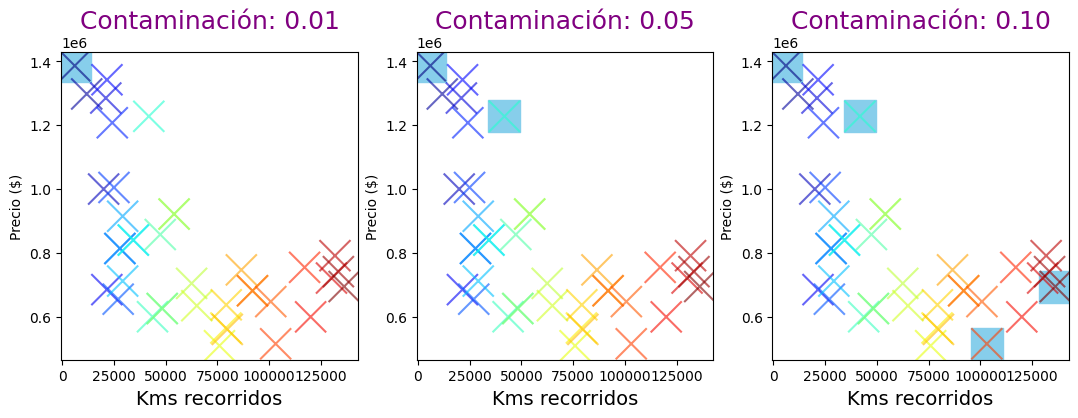

In [8]:
# Graficar datos anómalos
plt.set_cmap("jet")
fig = plt.figure(figsize=(13, 4))

for i in range(len(c)):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(carros[resultados[i]==-1][:, 0],
               carros[resultados[i]==-1][:, 1],
               c="skyblue", marker="s", s=500)
    ax.scatter(carros[:, 0],
               carros[:, 1],
               c=range(carros.size//2), marker="x",
               s=500, alpha=0.6)
    ax.set_title("Contaminación: %0.2f" % c[i], size=18, color="purple")
    ax.set_ylabel("Precio ($)", size=10)
    ax.set_xlabel("Kms recorridos", size=14)

plt.show()

En la grafica observamos que:
- Bajan los precios si sube el kilometraje
- Son valores anomalos los altos precios y altos kilometrajes
- Son valores anomalos los bajos precios con bajo kilometraje

1. **`carros[resultados[i]==-1][:, 0]`**: Este parámetro especifica las coordenadas `x` de los puntos a graficar. Aquí, `carros` es un array que contiene los datos de los carros usados, donde cada fila representa un carro y las columnas representan diferentes atributos de estos carros (por ejemplo, kilómetros recorridos y precio). `resultados[i] == -1` es una condición que filtra los carros identificados como anómalos por el modelo `IsolationForest` (es decir, los puntos de datos para los cuales el modelo predice un valor de `-1`). `[: , 0]` selecciona la primera columna de este subconjunto filtrado, que podría representar, por ejemplo, los kilómetros recorridos por cada carro.

2. **`carros[resultados[i]==-1][:, 1]`**: Este parámetro especifica las coordenadas `y` de los puntos a graficar. Siguiendo el mismo principio que el parámetro anterior, `[: , 1]` selecciona la segunda columna del subconjunto filtrado, que podría representar el precio de los carros.


3. **`carros[:, 0]`**: Este parámetro especifica las coordenadas `x` de los puntos a graficar. Aquí, `carros` es un array que contiene los datos, donde cada fila representa un carro y las columnas representan diferentes características de estos carros (por ejemplo, kilómetros recorridos y precio). Al usar `[:, 0]`, se selecciona la primera columna del array `carros`, que podría representar, por ejemplo, los kilómetros recorridos por cada carro.

4. **`carros[:, 1]`**: Este parámetro especifica las coordenadas `y` de los puntos a graficar. Al usar `[:, 1]`, se selecciona la segunda columna del array `carros`, que podría representar el precio de cada carro.

#**CON DATOS ESCALADOS**

<Figure size 640x480 with 0 Axes>

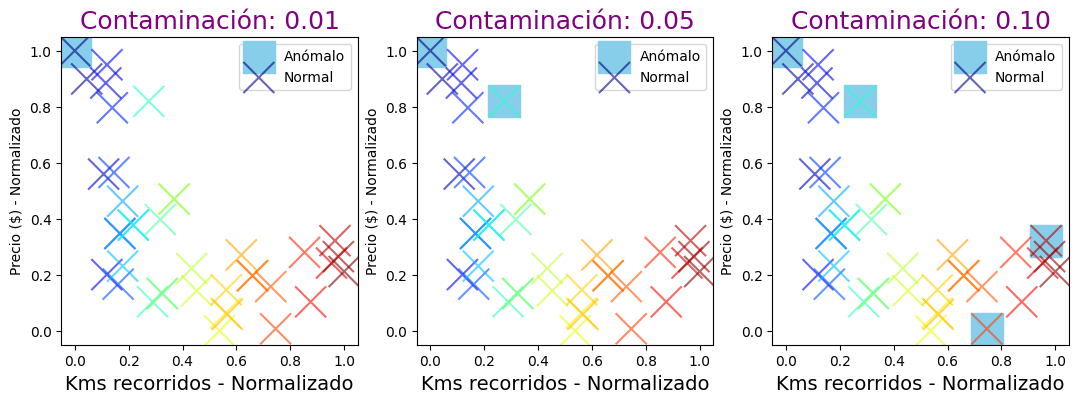

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

# Cargar datos: Se asume que "carros.csv" tiene dos columnas (por ejemplo, km y precio)
carros = np.loadtxt("carros.csv", delimiter=",", skiprows=1)  # km / precio

# Normalizar los datos para que cada característica se encuentre en el rango [0, 1]
scaler = MinMaxScaler()
carros_normalizados = scaler.fit_transform(carros)

# Inicializar matriz para almacenar los resultados de la detección de anomalías
resultados = np.zeros((3, carros_normalizados.shape[0]))

# Definir niveles de contaminación a evaluar
niveles_contaminacion = [0.01, 0.05, 0.1]

# Construir y aplicar el modelo Isolation Forest para cada nivel de contaminación
for i, contaminacion in enumerate(niveles_contaminacion):
    modelo = IsolationForest(contamination=contaminacion, random_state=42)
    modelo.fit(carros_normalizados)
    resultados[i] = modelo.predict(carros_normalizados)

# Graficar los resultados: puntos anómalos y todos los datos
plt.set_cmap("jet")
fig = plt.figure(figsize=(13, 4))

for i, contaminacion in enumerate(niveles_contaminacion):
    ax = fig.add_subplot(1, 3, i+1)

    # Graficar los datos identificados como anómalos (predicción == -1)
    ax.scatter(carros_normalizados[resultados[i] == -1][:, 0],
               carros_normalizados[resultados[i] == -1][:, 1],
               c="skyblue", marker="s", s=500, label="Anómalo")

    # Graficar todos los datos
    ax.scatter(carros_normalizados[:, 0],
               carros_normalizados[:, 1],
               c=range(carros_normalizados.shape[0]), marker="x",
               s=500, alpha=0.6, label="Normal")

    ax.set_title(f"Contaminación: {contaminacion:.2f}", size=18, color="purple")
    ax.set_ylabel("Precio ($) - Normalizado", size=10)
    ax.set_xlabel("Kms recorridos - Normalizado", size=14)
    ax.legend()

plt.show()
